# Task epsilon — the inventory model with stochastic demand: solution

The class model is extended by subclassing, so nothing from Tuesday is retyped. The
Bellman operator and the backwards induction solver are the deterministic ones with
one extra axis for demand, and the expectation over next period demand is a single
matrix-vector product. Section 5 adds a check that the simulator and the solver agree.

## The code from the finite horizon specification of the inventory model

Reusable code copied over from `inventory_stochastic.ipynb`, and then run in the next cell.

Observe how the implementation of the inventory model can be made a Python *module* loaded with `import` and run with the commands in the next cell. This is the good practice -- develop and illustrate code in a notebook, save as **.py** files and import as modules for actual use.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]

class inventory_model:
    '''Small class to hold model fundamentals and its solution'''

    def __init__(self,label='noname',
                 max_inventory=10,  # upper bound on the state space
                 c = 3.2,           # fixed cost of order
                 p = 2.5,           # profit per unit of good
                 r = 0.5,           # storage cost per unit of good
                 β = 0.95,          # discount factor
                 demand = 4         # fixed demand
                 ):
        '''Create model with default parameters'''
        self.label=label # label for the model instance
        self.c, self.p, self.r, self.β = c, p, r, β
        self.demand = demand
        self.n = max_inventory+1    # number of inventory levels
        self.upper = max_inventory  # upper boundary on inventory
        self.x = np.arange(self.n)  # all possible values of inventory (state space)

    def __repr__(self):
        '''String representation of the model'''
        return 'Inventory model labeled "{}"\nParamters (c,p,r,β) = ({},{},{},{})\nDemand={}\nUpper bound on inventory {}' \
               .format (self.label,self.c,self.p,self.r,self.β,self.demand,self.upper)

    def sales(self,x,d):
        '''Sales in given period'''
        return np.minimum(x,d)

    def next_x(self,x,d,q):
        '''Inventory to be stored, becomes next period state'''
        return x - self.sales(x,d) + q

    def profit(self,x,d,q):
        '''Profit in given period'''
        return self.p * self.sales(x,d) - self.r * self.next_x(x,d,q) - self.c * (q>0)

# 1. Random demand
class inventory_model_stochastic(inventory_model):
    '''Inventory model with truncated geometric demand on the inventory grid'''

    def __init__(self, λ=0.25, **kwargs):
        '''λ is the parameter of the geometric distribution, everything else as before'''
        super().__init__(**kwargs)
        self.λ = λ

    def __repr__(self):
        '''String representation of the model'''
        return ('Inventory model labeled "{}"\nParameters (c,p,r,β) = ({},{},{},{})\n'
                'Demand ~ truncated geometric with λ={}\nUpper bound on inventory {}'
                ).format(self.label,self.c,self.p,self.r,self.β,self.λ,self.upper)

    def demand_pr(self, plot=False):
        '''Probabilities of demand d=0,1,...,N: truncated geometric, last one corrected'''
        k = np.arange(self.n)                 # demand takes the same values as inventory
        pr = (1-self.λ)**k * self.λ
        pr[-1] = 1 - pr[:-1].sum()            # the truncated tail piles onto the last point
        if plot:
            plt.figure(figsize=(8,4))
            plt.bar(k, pr, width=0.8)
            plt.title(f'Distribution of demand, λ={self.λ}, mean {np.dot(k,pr):.2f}')
            plt.xlabel('demand d'); plt.ylabel('probability')
            plt.show()
        return pr

# 2. The Bellman operator with random demand
def bellman(m, v0):
    '''Bellman operator for the stochastic inventory model.
    Input:  model, and next period value function on the (d,x) grid, demand in rows
    Output: (v1, q1) — value and policy on the (d,x) grid
    '''
    pr = m.demand_pr()
    q = m.x[:,np.newaxis,np.newaxis]    # choices along axis 0, to be reduced
    d = m.x[np.newaxis,:,np.newaxis]    # demand along axis 1 (rows of the result)
    x = m.x[np.newaxis,np.newaxis,:]    # inventory along axis 2 (columns of the result)
    p = m.profit(x,d,q)                 # current profit, (q,d,x) array
    i = np.minimum(m.next_x(x,d,q), m.upper)   # next period inventory, capped at the grid
    ev = pr @ v0                        # expected next period value, as a function of x'
    vm = p + m.β*ev[i]                  # Bellman maximand
    v1 = np.amax(vm, axis=0)            # max over q for every (d,x)
    q1 = np.argmax(vm, axis=0)          # argmax = optimal order for every (d,x)
    return v1, q1

# 3. Backwards induction
def solver_backwards_induction(m, T=10, verbose=False):
    '''Backwards induction for the finite horizon stochastic inventory model'''
    # solution is time dependent: (demand, inventory, period) arrays
    m.value  = np.zeros((m.n,m.n,T))
    m.policy = np.zeros((m.n,m.n,T), dtype=int)
    d = m.x[:,np.newaxis]       # demand in rows
    x = m.x[np.newaxis,:]       # inventory in columns
    # main DP loop (from T to 1)
    for t in range(T,0,-1):
        j = t-1   # index of value and policy functions for period t
        if t==T:
            # terminal period: ordering zero is optimal
            m.value[:,:,j] = m.profit(x,d,0)
        else:
            # all other periods: next period value to Bellman
            m.value[:,:,j], m.policy[:,:,j] = bellman(m, m.value[:,:,j+1])
        if verbose:
            print('Time period %d, optimal orders (demand in rows, inventory in columns)' % t)
            print(m.policy[:,:,j], '\n')
    # return model with updated value and policy functions
    return m

# 4. Look at the solution
def plot_solution_xd(m, t=1, demands=(0,2,4,8,12)):
    '''Value and policy of period t against inventory, one line per level of demand'''
    j = t-1
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
    for d in demands:
        ax1.step(m.x, m.value[d,:,j],  where='mid', label=f'd={d}')
        ax2.step(m.x, m.policy[d,:,j], where='mid', label=f'd={d}')
    ax1.set_title(f'Value function in period {t}')
    ax2.set_title(f'Optimal order in period {t}')
    for ax in (ax1,ax2):
        ax.set_xlabel('inventory x'); ax.legend(frameon=False); ax.grid(alpha=.3)
    plt.show()

# 5. Simulator for the model
def simulator(m, x0=0, t0=1, periods=None, seed=None, plot=True):
    '''Simulate the solved finite horizon model from inventory x0 in period t0.
    Runs for the given number of periods, or until the last period T of the solution.
    Returns a dict with periods, demand, inventory (one longer, the stock carried into
    the period after the last), orders and profits.
    '''
    T = m.policy.shape[2]
    if periods is None or periods > T-t0+1:
        periods = T-t0+1                       # policy is not defined beyond T
    rng = np.random.default_rng(seed)
    d = rng.choice(m.x, size=periods, p=m.demand_pr())   # i.i.d. draws of demand
    x = np.zeros(periods+1, dtype=int); x[0] = x0
    q = np.zeros(periods, dtype=int)
    profit = np.zeros(periods)
    for k in range(periods):
        t = t0 + k
        q[k] = m.policy[d[k], x[k], t-1]                     # optimal order at (d,x) in period t
        profit[k] = m.profit(x[k], d[k], q[k])
        x[k+1] = min(m.next_x(x[k], d[k], q[k]), m.upper)    # the cap never binds, see text
    sim = dict(t=np.arange(t0, t0+periods), d=d, x=x[:-1], x_next=x[-1], q=q, profit=profit)
    if plot:
        plot_simulation(sim, m)
    return sim

def plot_simulation(sim, m):
    '''Inventory and demand, orders, and profit over time'''
    fig, axes = plt.subplots(3,1,figsize=(12,9),sharex=True)
    t = sim['t']
    axes[0].step(t, sim['x'], where='mid', lw=2, label='inventory at the start of the period')
    axes[0].step(t, sim['d'], where='mid', lw=1, ls='--', label='demand')
    axes[0].set_ylabel('units'); axes[0].legend(frameon=False)
    axes[1].bar(t, sim['q'], width=0.6)
    axes[1].set_ylabel('order')
    axes[2].step(t, sim['profit'], where='mid', lw=2, label='profit')
    axes[2].step(t, np.cumsum(sim['profit'] * m.β**(t-t[0])), where='mid', lw=1, ls='--',
                 label='cumulative discounted profit')
    axes[2].axhline(0, color='k', lw=.5)
    axes[2].set_ylabel('profit'); axes[2].set_xlabel('period t'); axes[2].legend(frameon=False)
    for ax in axes: ax.grid(alpha=.3)
    axes[0].set_title(f'Simulation of "{m.label}" from x={sim["x"][0]} in period {t[0]}')
    plt.show()

Inventory model labeled "Finite horizon model"
Parameters (c,p,r,β) = (1.37,2.5,0.5,0.95)
Demand ~ truncated geometric with λ=0.25
Upper bound on inventory 20


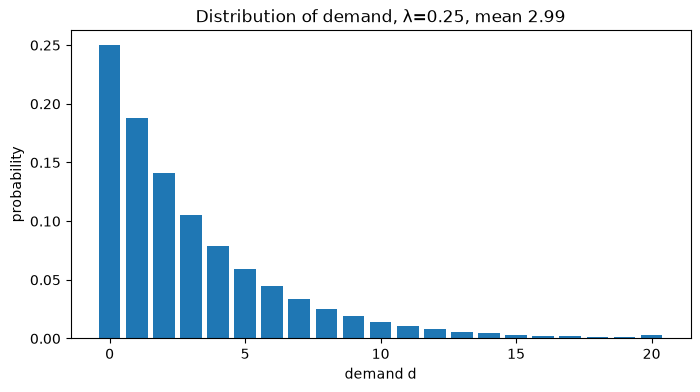

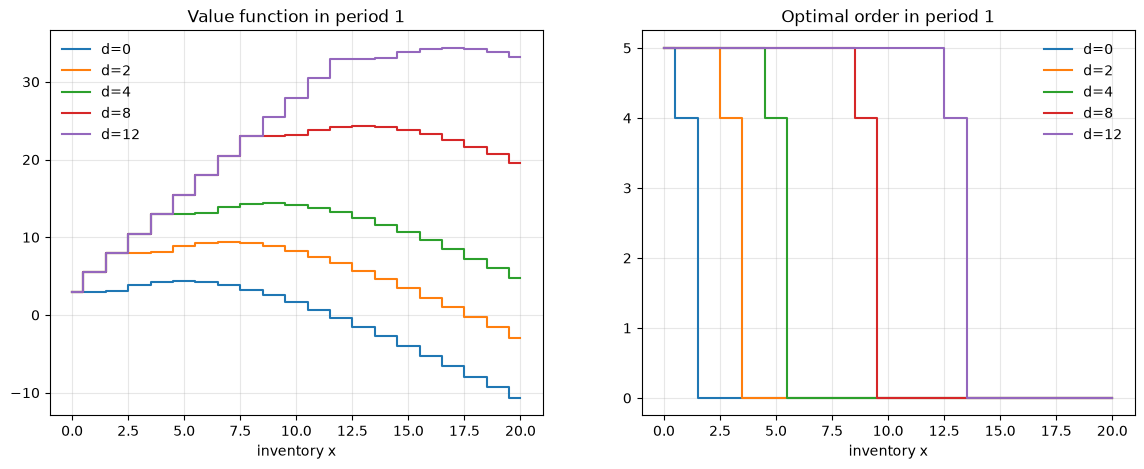

Optimal order in period 1, demand in rows, inventory in columns:
[[5 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [5 5 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [5 5 5 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [5 5 5 5 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [5 5 5 5 5 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [5 5 5 5 5 5 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [5 5 5 5 5 5 5 4 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [5 5 5 5 5 5 5 5 4 0 0 0 0 0 0 0 0 0 0 0 0]
 [5 5 5 5 5 5 5 5 5 4 0 0 0 0 0 0 0 0 0 0 0]
 [5 5 5 5 5 5 5 5 5 5 4 0 0 0 0 0 0 0 0 0 0]
 [5 5 5 5 5 5 5 5 5 5 5 4 0 0 0 0 0 0 0 0 0]
 [5 5 5 5 5 5 5 5 5 5 5 5 4 0 0 0 0 0 0 0 0]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 4 0 0 0 0 0 0 0]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 4 0 0 0 0 0 0]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 4 0 0 0 0 0]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 4 0 0 0 0]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 4 0 0 0]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 4 0 0]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 4 0]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 4]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5

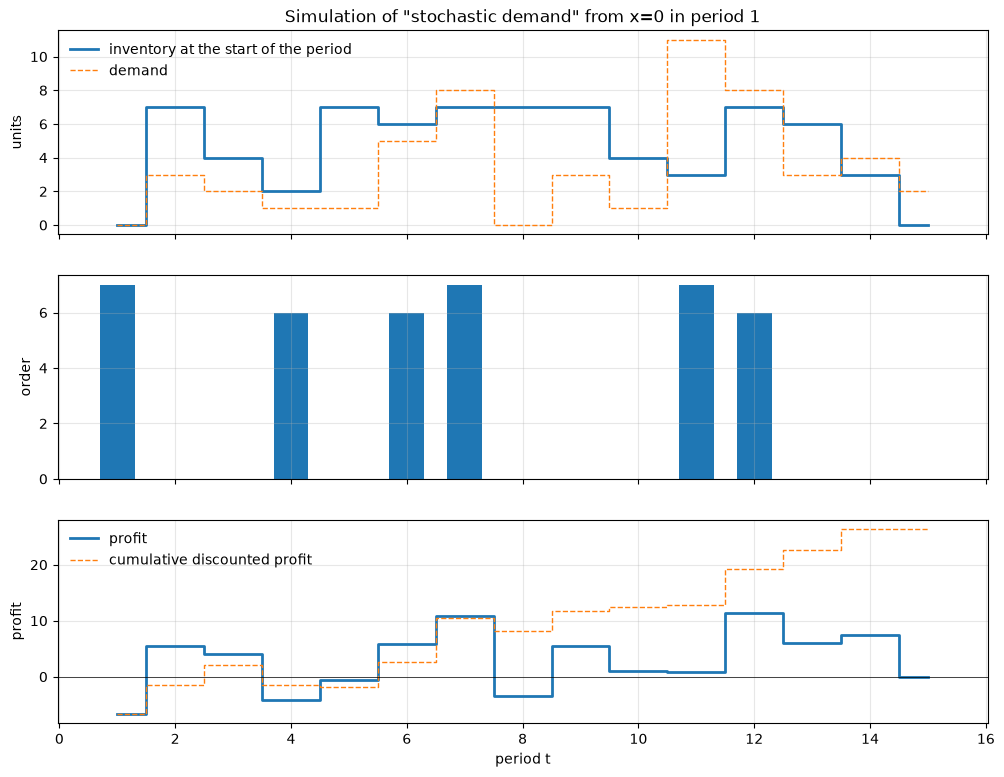

In [26]:
m = inventory_model_stochastic(label='Finite horizon model', max_inventory=20, λ=0.25, c=1.37)
print(m)
pr = m.demand_pr(plot=True)
m = solver_backwards_induction(m, T=3, verbose=False)
plot_solution_xd(m)
np.set_printoptions(linewidth=160)
print('Optimal order in period 1, demand in rows, inventory in columns:')
print(m.policy[:,:,0])

mod = inventory_model_stochastic(label='stochastic demand', max_inventory=25, λ=0.25)
mod = solver_backwards_induction(mod, T=15)
sim = simulator(mod, x0=0, t0=1, seed=2026)

## What needs to change to implement VFI and solve the infinite horizon version model?


In [27]:
# VFI implementation for the infinite horizon model

def solve_vfi(m,tol=1e-6,maxiter=500,callback=None):
    '''Backwards induction for the finite horizon stochastic inventory model'''
    # solution is time dependent: (demand, inventory) arrays, time independent
    m.value  = np.zeros((m.n,m.n))
    m.policy = np.zeros((m.n,m.n), dtype=int)
    d = m.x[:,np.newaxis]       # demand in rows
    x = m.x[np.newaxis,:]       # inventory in columns
    # main VFI loop
    v0=m.value.copy()
    for i in range(maxiter):
        m.value, m.policy = bellman(m, v0)
        err = np.amax(np.abs(m.value-v0),keepdims=False)
        if callback: callback(iter=i,err=err,model=m)
        if err<tol:
            break
        v0 = m.value.copy()
    else:
        raise RuntimeError('Failed to converge in %d iterations'%maxiter)
    return m

def solve_show(model,maxiter=1000,tol=1e-6,demand=[5],**kvargs):
    '''Solve and plot the convergence path'''
    nd=len(demand)
    fig1, axs = plt.subplots(nd,2,figsize=(14,6*nd))
    print(type(axs),axs.shape)
    for i in range(nd):
        for ax,ttl,xlab in ((axs[i,0],f'Expected value function  (demand={demand[i]})','Inventory'),
                            (axs[i,1],f'Optimal new orders (demand={demand[i]})','Inventory')):
            ax.grid(visible=True, which='both', color='0.65', linestyle='-')
            ax.set_title(ttl)
            ax.set_xlabel(xlab)
    def callback(**argvars):
        mod = argvars['model']
        for i in range(nd):
            ax1,ax2 = axs[i,0],axs[i,1]
            ax1.step(mod.x,mod.value[demand[i],:],color='k',alpha=0.25,where='mid')
            ax2.step(mod.x,mod.policy[demand[i],:],color='k',alpha=0.25,where='mid')
    mod = solve_vfi(model,maxiter=maxiter,tol=tol,callback=callback,**kvargs)
    for i in range(nd):
        ax1,ax2 = axs[i,0],axs[i,1]
        ax1.step(mod.x,mod.value[demand[i],:],color='r',linewidth=2.5,where='mid')
        ax2.step(mod.x,mod.policy[demand[i],:],color='r',linewidth=2.5,where='mid')
    plt.show()

Inventory model labeled "Finite horizon model"
Parameters (c,p,r,β) = (2.37,2.5,0.5,0.95)
Demand ~ truncated geometric with λ=0.25
Upper bound on inventory 20
<class 'numpy.ndarray'> (5, 2)


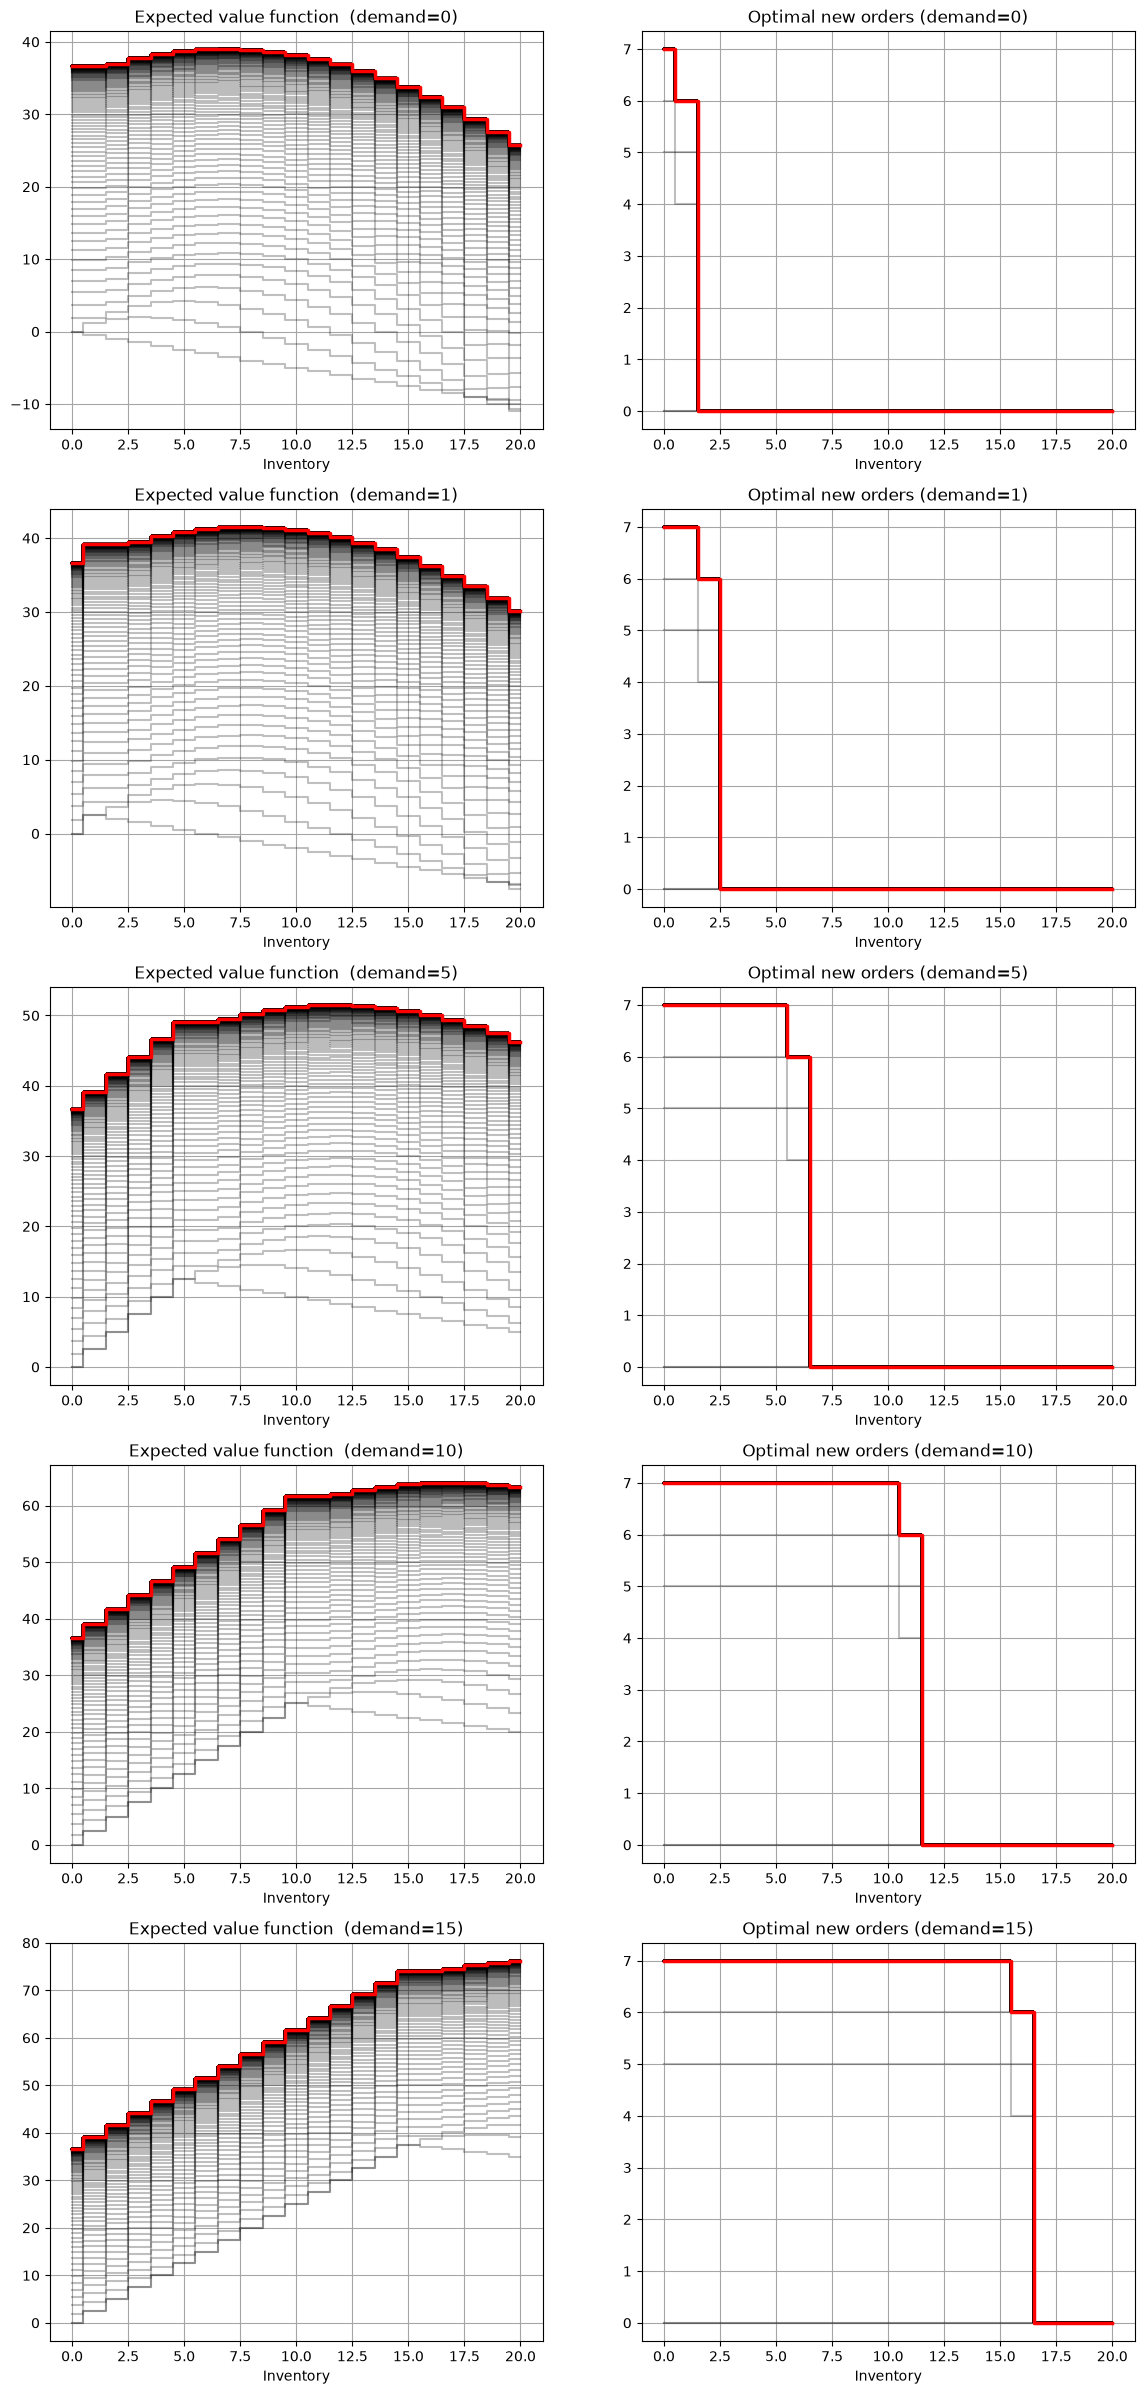

[[36.64 36.64 37.01 37.76 38.33 38.72 38.95 39.01 38.9  38.63 38.2  37.62 36.88 35.99 34.94 33.76 32.43 30.95 29.34 27.59 25.7 ]
 [36.64 39.14 39.14 39.51 40.26 40.83 41.22 41.45 41.51 41.4  41.13 40.7  40.12 39.38 38.49 37.44 36.26 34.93 33.45 31.84 30.09]
 [36.64 39.14 41.64 41.64 42.01 42.76 43.33 43.72 43.95 44.01 43.9  43.63 43.2  42.62 41.88 40.99 39.94 38.76 37.43 35.95 34.34]
 [36.64 39.14 41.64 44.14 44.14 44.51 45.26 45.83 46.22 46.45 46.51 46.4  46.13 45.7  45.12 44.38 43.49 42.44 41.26 39.93 38.45]
 [36.64 39.14 41.64 44.14 46.64 46.64 47.01 47.76 48.33 48.72 48.95 49.01 48.9  48.63 48.2  47.62 46.88 45.99 44.94 43.76 42.43]
 [36.64 39.14 41.64 44.14 46.64 49.14 49.14 49.51 50.26 50.83 51.22 51.45 51.51 51.4  51.13 50.7  50.12 49.38 48.49 47.44 46.26]
 [36.64 39.14 41.64 44.14 46.64 49.14 51.64 51.64 52.01 52.76 53.33 53.72 53.95 54.01 53.9  53.63 53.2  52.62 51.88 50.99 49.94]
 [36.64 39.14 41.64 44.14 46.64 49.14 51.64 54.14 54.14 54.51 55.26 55.83 56.22 56.45 56.51 56.4 

In [28]:
m = inventory_model_stochastic(label='Finite horizon model', max_inventory=20, λ=0.25, c=2.37)
print(m)
solve_vfi(m)

solve_show(m,demand=[0,1,5,10,15])

with np.printoptions(precision=2):
    print(m.value)
    print(m.policy)

# save for later check
value2d = m.value
policy2d = m.policy

## Tricks: Bellman operator in expected value space and post-decision variable

In [29]:
def bellman_ev(m,ev0):
    '''Vectorized version of bellman_ev: the loop over demand becomes a third broadcasting axis
        Input:  ev0, the current guess of EV(x) on the state space
        Output: ev1, the updated EV
    '''
    pr = m.demand_pr()
    q = m.x[:,np.newaxis,np.newaxis]    # choices along axis 0, to be reduced
    d = m.x[np.newaxis,:,np.newaxis]    # demand along axis 1
    x = m.x[np.newaxis,np.newaxis,:]    # inventory along axis 2
    p = m.profit(x,d,q)                 # current profit, (q,d,x) array
    i = np.minimum(m.next_x(x,d,q),m.upper)   # next period stock, capped at the grid
    vm = p + m.β*ev0[i]                 # Bellman maximand
    v1 = np.amax(vm,axis=0)             # V(d,x): max over q for every (d,x)
    return pr @ v1                      # EV(x) = sum over d of pr(d) V(d,x)

def solve_vfi_ev(m,tol=1e-6,maxiter=500,callback=None):
    '''Value function iterations on the expected value function'''
    ev0 = np.zeros(m.n)
    for i in range(maxiter):
        ev1 = bellman_ev(m,ev0)
        err = np.amax(np.abs(ev0-ev1))
        if callback: callback(iter=i,err=err,model=m,ev1=ev1)
        if err<tol:
            break
        ev0 = ev1
    else:
        raise RuntimeError('Failed to converge in %d iterations'%maxiter)
    m.exp_value = ev1
    return m

def optimal_policy_1d(m,ev=None):
    '''Optimal order as a function of the post-trade stock y = max(x-d,0)'''
    if ev is None:
        ev = m.exp_value
    q = m.x[:,np.newaxis]  # choices in rows
    y = m.x[np.newaxis,:]  # post-trade stock in columns
    i = np.minimum(y+q,m.upper)
    vm = -m.r*q - m.c*(q>0) + m.β*ev[i]   # terms that involve q only
    return np.argmax(vm,axis=0)

def solve_show_ev(model,maxiter=1000,tol=1e-6,**kvargs):
    '''Solve and plot the convergence path'''
    fig1, (ax1,ax2) = plt.subplots(1,2,figsize=(14,6))
    for ax,ttl,xlab in ((ax1,'Expected value function','Inventory'),
                        (ax2,'Optimal new orders','Post-trade stock')):
        ax.grid(visible=True, which='both', color='0.65', linestyle='-')
        ax.set_title(ttl)
        ax.set_xlabel(xlab)
    def callback(**argvars):
        mod, ev = argvars['model'],argvars['ev1']
        ax1.step(mod.x,ev,color='k',alpha=0.25,where='mid')
        ax2.step(mod.x,optimal_policy_1d(mod,ev),color='k',alpha=0.25,where='mid')
    mod = solve_vfi_ev(model,maxiter=maxiter,tol=tol,callback=callback,**kvargs)
    ax1.step(mod.x,mod.exp_value,color='r',linewidth=2.5,where='mid')
    ax2.step(mod.x,optimal_policy_1d(mod),color='r',linewidth=2.5,where='mid')
    plt.show()

def solution_ev(model):
    '''Return model solution in 2D arrays for value and policy functions for comparison'''
    # the following lines are from previous version of Bellman
    q = m.x[:,np.newaxis,np.newaxis]    # choices along axis 0, to be reduced
    d = m.x[np.newaxis,:,np.newaxis]    # demand along axis 1 (rows of the result)
    x = m.x[np.newaxis,np.newaxis,:]    # inventory along axis 2 (columns of the result)
    p = m.profit(x,d,q)                 # current profit, (q,d,x) array
    i = np.minimum(m.next_x(x,d,q), m.upper)   # next period inventory, capped at the grid
    ev = model.exp_value # expected next period value, as a function of x'
    vm = p + m.β*ev[i]                  # Bellman maximand
    v1 = np.amax(vm, axis=0)            # max over q for every (d,x)
    q1 = np.argmax(vm, axis=0)          # argmax = optimal order for every (d,x)
    return v1, q1


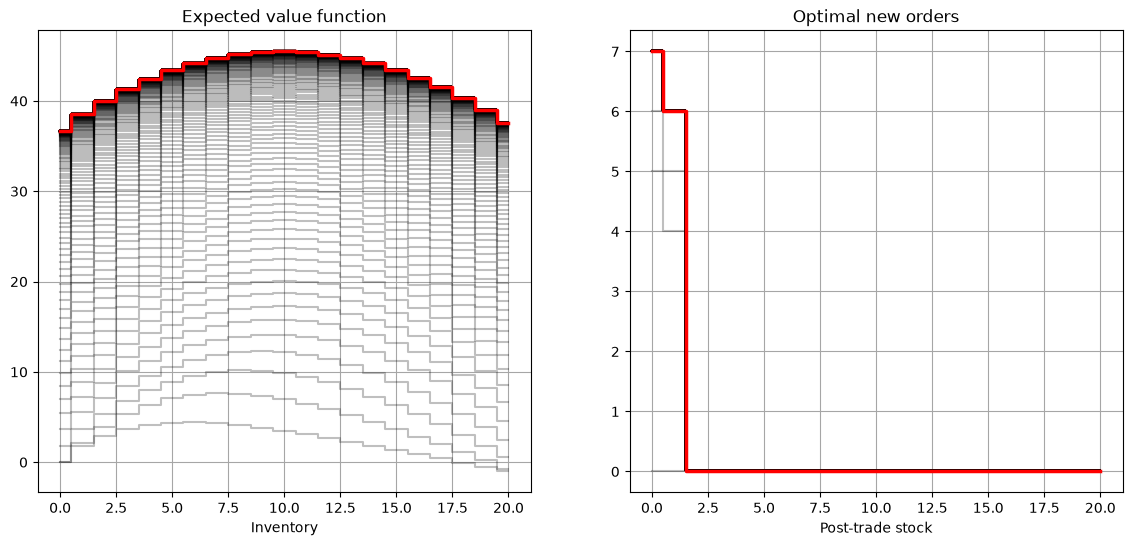

Expected value and policy as function of post-trade stock y = max(x-d,0):
[36.64 38.51 40.01 41.32 42.45 43.39 44.16 44.74 45.16 45.4  45.48 45.39 45.13 44.72 44.15 43.43 42.55 41.53 40.35 39.04 37.58]
[7 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Value and policy as function of both stock and demand realization:
[[36.64 36.64 37.01 37.76 38.33 38.72 38.95 39.01 38.9  38.63 38.2  37.62 36.88 35.99 34.94 33.76 32.43 30.95 29.34 27.59 25.7 ]
 [36.64 39.14 39.14 39.51 40.26 40.83 41.22 41.45 41.51 41.4  41.13 40.7  40.12 39.38 38.49 37.44 36.26 34.93 33.45 31.84 30.09]
 [36.64 39.14 41.64 41.64 42.01 42.76 43.33 43.72 43.95 44.01 43.9  43.63 43.2  42.62 41.88 40.99 39.94 38.76 37.43 35.95 34.34]
 [36.64 39.14 41.64 44.14 44.14 44.51 45.26 45.83 46.22 46.45 46.51 46.4  46.13 45.7  45.12 44.38 43.49 42.44 41.26 39.93 38.45]
 [36.64 39.14 41.64 44.14 46.64 46.64 47.01 47.76 48.33 48.72 48.95 49.01 48.9  48.63 48.2  47.62 46.88 45.99 44.94 43.76 42.43]
 [36.64 39.14 41.64 44.14 46.64 49.14 49.

In [30]:
solve_show_ev(m)

with np.printoptions(precision=2):
    print('Expected value and policy as function of post-trade stock y = max(x-d,0):')
    print(m.exp_value)
    print(optimal_policy_1d(m))
    # compare to the previous solution
    v,q = solution_ev(m)
    print('\nValue and policy as function of both stock and demand realization:')
    print(v)
    print(q)
    print('\nDifference from the previous solution (order of magnitude for values):')
    print(np.log10(v-value2d))
    print(q-policy2d)




In [31]:
# which version is faster?
# mt = inventory_model_stochastic(max_inventory=100, λ=0.25, c=2.37)
# %timeit solve_vfi(mt,tol=1e-12,maxiter=1000)
# %timeit solve_vfi_ev(mt,tol=1e-12,maxiter=1000)


## Simulator in infinite horizon

In [ ]:
def simulator(m, x0=0, periods=100, seed=None, plot=True):
    '''Simulate the solved infinite horizon model from inventory x0 for a given number of periods.
    Uses only the expected value function: the optimal order is a stationary function of the
    post-trade stock y = max(x-d,0), computed by optimal_policy_1d from m.exp_value.
    Returns a dict with periods, demand, inventory (one longer, the stock carried into
    the period after the last), post-trade stock, orders and profits.
    '''
    policy = optimal_policy_1d(m)                        # q*(y), the same in every period
    rng = np.random.default_rng(seed)
    d = rng.choice(m.x, size=periods, p=m.demand_pr())   # i.i.d. draws of demand
    x = np.zeros(periods+1, dtype=int); x[0] = x0
    y = np.zeros(periods, dtype=int)
    q = np.zeros(periods, dtype=int)
    profit = np.zeros(periods)
    for k in range(periods):
        y[k] = x[k] - m.sales(x[k], d[k])                # post-trade stock, all the order depends on
        q[k] = policy[y[k]]                              # optimal order
        profit[k] = m.profit(x[k], d[k], q[k])
        x[k+1] = min(y[k] + q[k], m.upper)               # next period inventory
    sim = dict(t=np.arange(1, periods+1), d=d, x=x[:-1], x_next=x[-1], y=y, q=q, profit=profit)
    if plot:
        plot_simulation(sim, m)
    return sim

def plot_simulation(sim, m):
    '''Six panels in the order of events within a period: inventory, demand, post-trade stock,
    order, profit, cumulative discounted profit. Stocks are step functions, flows are bars.
    '''
    t = sim['t']
    cumprofit = np.cumsum(sim['profit'] * m.β**(t-t[0]))
    panels = [  # (series, title, kind, color)
        (sim['x'],      'Inventory at the start of the period',     'step', '#2a78d6'),
        (sim['d'],      'Demand',                                   'bar',  '#eb6834'),
        (sim['y'],      'Post-trade stock y = max(x-d,0)',          'step', '#1baf7a'),
        (sim['q'],      'Order',                                    'bar',  '#eda100'),
        (sim['profit'], 'Profit',                                   'bar',  '#e87ba4'),
        (cumprofit,     'Cumulative discounted profit',             'step', '#008300'),
    ]
    fig, axes = plt.subplots(len(panels), 1, figsize=(12,16), sharex=True)
    for ax, (series, title, kind, color) in zip(axes, panels):
        if kind == 'bar':
            ax.bar(t, series, width=0.8, color=color)
        else:
            ax.step(t, series, where='mid', lw=2, color=color)
        ax.axhline(0, color='k', lw=.5)
        ax.set_title(title, loc='left', fontsize=11)
        ax.grid(alpha=.3)
    axes[-1].set_xlabel('period t')
    fig.suptitle(f'Simulation of "{m.label}" from x={sim["x"][0]} in period {t[0]}', y=0.995)
    fig.tight_layout()
    plt.show()


Inventory model labeled "Model for simulation"
Parameters (c,p,r,β) = (62,2.1,0.15,0.95)
Demand ~ truncated geometric with λ=0.04
Upper bound on inventory 100


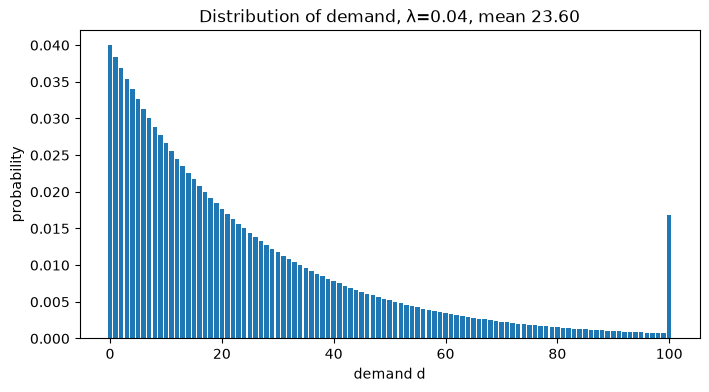

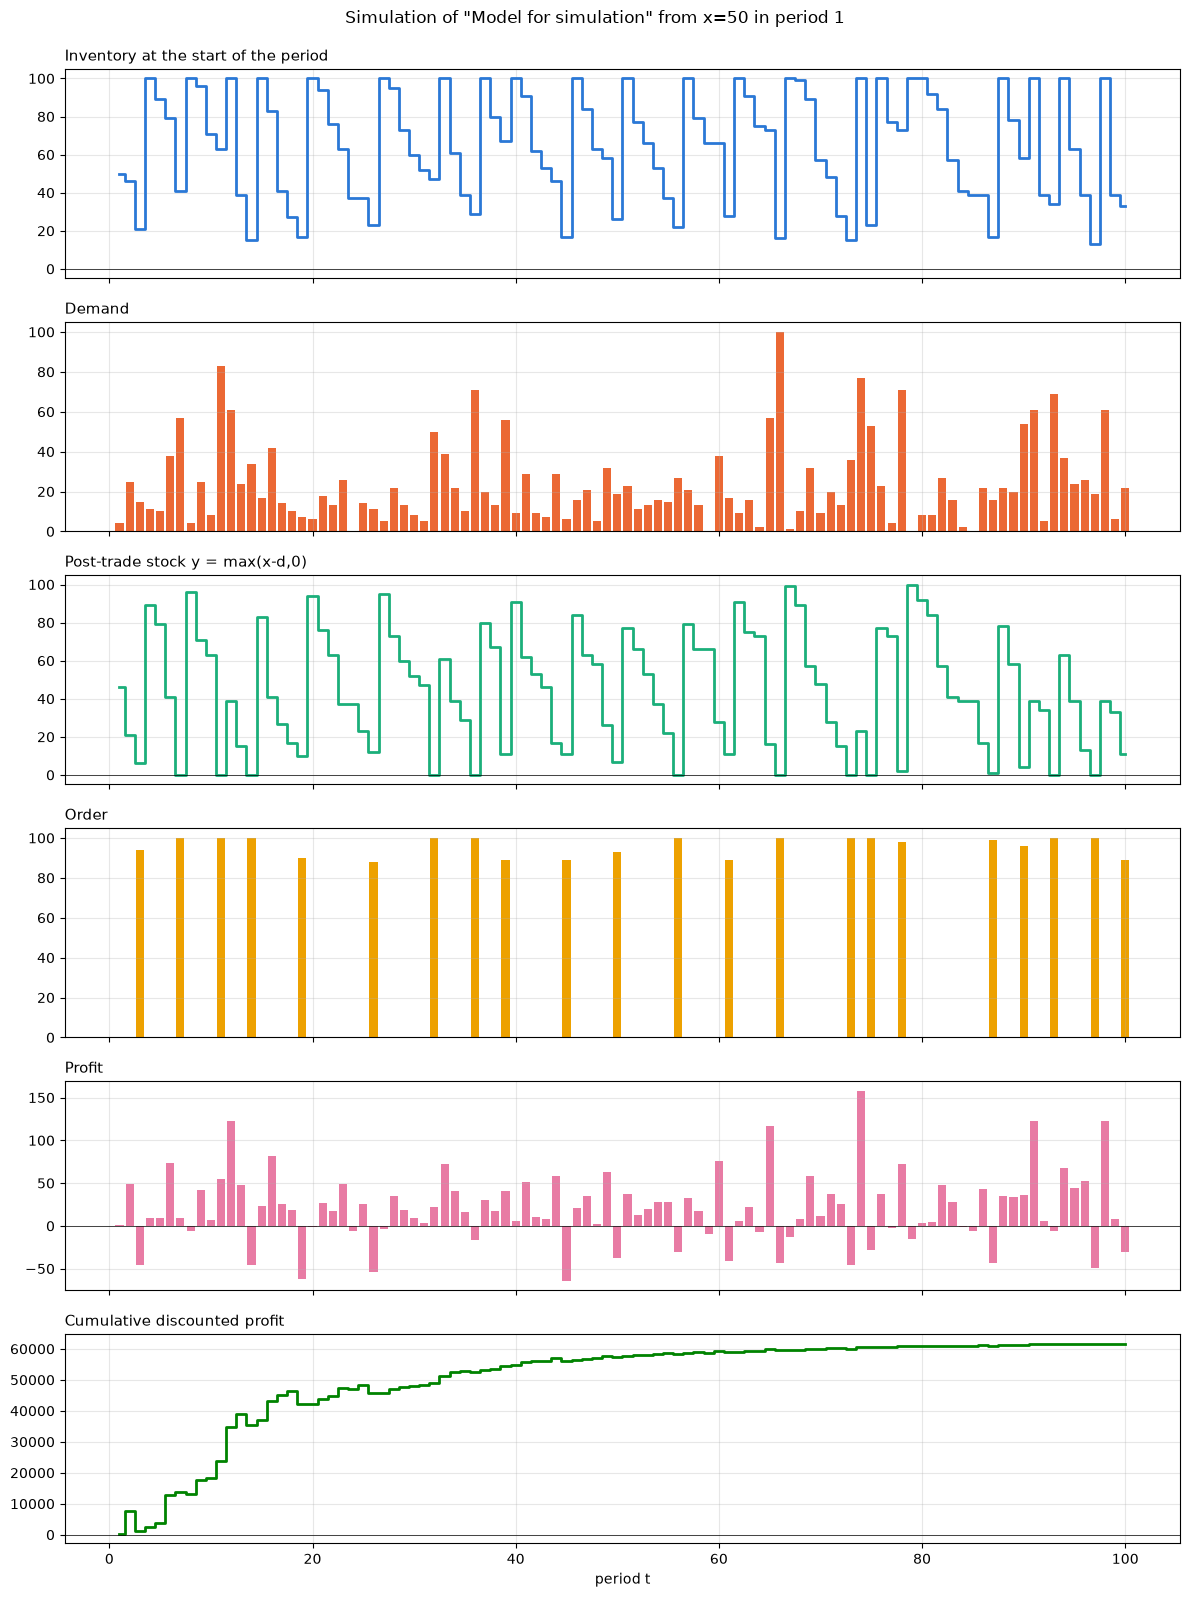

In [35]:
mdl = inventory_model_stochastic(label='Model for simulation', max_inventory=100, λ=0.04, c=62, p=2.1, r=0.15)
print(mdl)
pr = mdl.demand_pr(plot=True)
mdl = solve_vfi_ev(mdl)
sim = simulator(mdl, x0=mdl.upper/2, seed=2026)
